## Dropout

- 我们实现``dropout_layer``函数，该函数以``dropout``的概率丢弃张量输入的``X``中的元素。

In [5]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


In [ ]:
print(device)

In [6]:
import torch
from torch import nn
from d2l import torch as d2l

def dropout_layer(X, dropout):
    assert 0 <= dropout <= 1 # 确保丢弃率在合理范围内
    if dropout == 1: # 如果丢弃率为1，则丢弃所有元素，返回一个全零的张量
        return torch.zeros_like(X)
    if dropout == 0: # 如果丢弃率为0，则不丢弃任何元素，直接返回输入
        return X
    mask = (torch.rand(X.shape,device=device) > dropout).float()
    # X[mask == 0] = 0 # 将丢弃的元素置零,这里不直接修改X，而是通过乘以mask来实现丢弃是为了适配GPU
    return mask * X / (1.0 - dropout) #这里乘mask是将丢弃的元素置零，也就是更改X，除以(1.0 - dropout)是为了保持输出的期望值不变

- 测试 ``dropout_layer``函数

In [2]:
X = torch.arange(16).reshape((2, 8))
print(X)
print(dropout_layer(X, 0.))
print(dropout_layer(X, 0.5))
print(dropout_layer(X, 1.))
# 丢弃率为0.5的时候，输出的元素大约有一半被丢弃了，且被丢弃的元素被置零了。没有被丢弃的就变大了，确保期望不变

tensor([[ 0,  1,  2,  3,  4,  5,  6,  7],
        [ 8,  9, 10, 11, 12, 13, 14, 15]])
tensor([[ 0,  1,  2,  3,  4,  5,  6,  7],
        [ 8,  9, 10, 11, 12, 13, 14, 15]])
tensor([[ 0.,  0.,  4.,  6.,  8., 10., 12., 14.],
        [16.,  0.,  0., 22., 24.,  0.,  0., 30.]])
tensor([[0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0]])


- 定义有两个隐藏层的多层感知机，每个隐藏层包含256个单元

In [9]:
num_inputs, num_outputs, num_hiddens1, num_hiddens2 = 784, 10, 256, 256

dropout1, dropout2 = 0.2, 0.5

class Net(nn.Module):
    def __init__(self, num_inputs, num_outputs, num_hiddens1, num_hiddens2,
                 is_training = True):
        super(Net, self).__init__()
        self.num_inputs = num_inputs
        self.training = is_training
        self.lin1 = nn.Linear(num_inputs, num_hiddens1)
        self.lin2 = nn.Linear(num_hiddens1, num_hiddens2)
        self.lin3 = nn.Linear(num_hiddens2, num_outputs)
        self.relu = nn.ReLU()

    def forward(self, X):
        H1 = self.relu(self.lin1(X.reshape((-1, self.num_inputs))))
        # 只有在训练模型时才使用dropout
        if self.training == True:
            # 在第一个全连接层之后添加一个dropout层
            H1 = dropout_layer(H1, dropout1)
        H2 = self.relu(self.lin2(H1))
        if self.training == True:
            # 在第二个全连接层之后添加一个dropout层
            H2 = dropout_layer(H2, dropout2)
        out = self.lin3(H2)
        return out


net = Net(num_inputs, num_outputs, num_hiddens1, num_hiddens2)
net = net.to(device)

- 训练和测试

(0.33325852348009743, 0.8777166666666667, 0.8336)

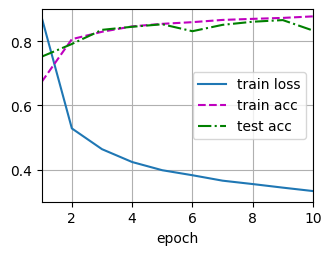

In [10]:
import sys
sys.path.append("..")
from my_utils import train_ch3
num_epochs, lr, batch_size = 10, 0.5, 256
loss = nn.CrossEntropyLoss()
train_iter, test_iter = d2l.load_data_fashion_mnist(batch_size)
trainer = torch.optim.SGD(net.parameters(), lr=lr)
train_ch3(net, train_iter, test_iter, loss, num_epochs, trainer)

# 简洁实现

In [11]:
net = nn.Sequential(nn.Flatten(),
        nn.Linear(784, 256),
        nn.ReLU(),
        # 在第一个全连接层之后添加一个dropout层
        nn.Dropout(dropout1),
        nn.Linear(256, 256),
        nn.ReLU(),
        # 在第二个全连接层之后添加一个dropout层
        nn.Dropout(dropout2),
        nn.Linear(256, 10))

def init_weights(m):
    if type(m) == nn.Linear:
        nn.init.normal_(m.weight, std=0.01)

net.apply(init_weights);